# Calcium Signal Fitting from RCamp Data

## Goal
Fit a parameterized Ca²⁺(t) curve from raw RCamp fluorescence (ionomycin stimulation) for use as time-dependent calcium input in CaMKK2 ODE models. Output: `Ca(t)` in **μM**, time in **seconds**.

## Pipeline
1. Load raw RCamp fluorescence from Excel (not normalized NPZ)
2. Fit bi-exponential to raw fluorescence (establishes transient shape)
3. Identify RCamp variant via Hill equation calibration (jRCaMP1a vs RCaMP1h)
4. Hill-calibrate raw data → [Ca²⁺] in μM, then re-fit bi-exponential
5. Save parameters to JSON, provide JAX-compatible `Ca(t)` for ODE solvers

## Data Source
- **Excel**: `260307_HeLaAMPKAR3_LKB1wt_kd.xlsx`, columns 16–17 (RCamp Iono `MEAN_RFPnorm`, `STD_RFPnorm`)
- Drug protocol: 5 mM CaCl₂ at t=4.5 min, 500 nM ionomycin at t=6.5 min, 0.5-min sampling

## Key Assumptions
- **Basal [Ca²⁺] = 0.1 μM**: resting cytosolic Ca²⁺ in HeLa; matches CaMKK2 model IC
- **RCaMP1h indicator** (Kd=1.3 μM, n=2.5): identified via Hill calibration (Section 3)
- **No F_max calibration**: F_max estimated from published dynamic range (10.6×)
- **Constant kGly during Iono**: no glycolysis inhibition; stress is purely Ca²⁺ → CaMKK2
- **No RCamp–CaM competition correction**: ~10% effect absorbed into fit (see `docs/calcium_camkk2_plan.md`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import json
import os

## 1. Load raw RCamp data

Raw `MEAN_RFPnorm` from Excel (not min-max normalized NPZ, which destroys the transient shape). Post-drug data shifted so ionomycin addition = t=0.

In [2]:
data_dir = '../../../AMPKARkey_data'
hela_raw = pd.read_excel(os.path.join(data_dir, '260307_HeLaAMPKAR3_LKB1wt_kd.xlsx'),
                          sheet_name='Sheet1', skiprows=2, header=None)
hela_time = pd.to_numeric(hela_raw.iloc[:, 0])

# RCamp calcium: columns 16-17 (Iono), 21-22 (2DG)
rcamp_iono_mean = pd.to_numeric(hela_raw.iloc[:, 16], errors='coerce')
rcamp_iono_std  = pd.to_numeric(hela_raw.iloc[:, 17], errors='coerce')

t_iono = 6.5  # ionomycin addition time (min)

# Trim to post-drug and shift so drug = t=0
mask_post = hela_time >= t_iono
t_post = (hela_time[mask_post] - t_iono).values   # minutes
y_post = rcamp_iono_mean[mask_post].values
s_post = rcamp_iono_std[mask_post].values

# Pre-drug baseline
baseline = rcamp_iono_mean[hela_time < t_iono].mean()

print(f"Pre-drug baseline: {baseline:.4f}")
print(f"Peak: {y_post.max():.4f} at t = {t_post[y_post.argmax()]:.1f} min")
print(f"Final: {y_post[-1]:.4f} at t = {t_post[-1]:.1f} min")
print(f"Post-drug points: {len(t_post)}")

Pre-drug baseline: 0.9501
Peak: 3.3091 at t = 1.5 min
Final: 1.6856 at t = 23.5 min
Post-drug points: 48


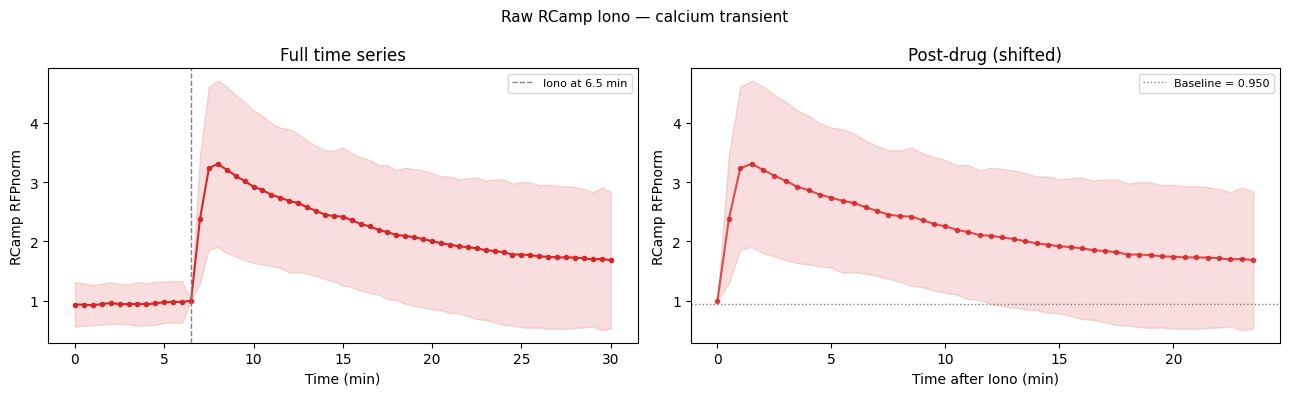

In [3]:
# Plot raw data: full time series and post-drug
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full time series
ax = axes[0]
ax.plot(hela_time, rcamp_iono_mean, 'o-', markersize=3, color='tab:red')
ax.fill_between(hela_time, rcamp_iono_mean - rcamp_iono_std, rcamp_iono_mean + rcamp_iono_std,
                alpha=0.15, color='tab:red')
ax.axvline(t_iono, color='grey', ls='--', lw=1, label=f'Iono at {t_iono} min')
ax.set_xlabel('Time (min)')
ax.set_ylabel('RCamp RFPnorm')
ax.set_title('Full time series')
ax.legend(fontsize=8)

# Post-drug
ax = axes[1]
ax.plot(t_post, y_post, 'o-', markersize=3, color='tab:red', alpha=0.8)
ax.fill_between(t_post, y_post - s_post, y_post + s_post, alpha=0.15, color='tab:red')
ax.axhline(baseline, color='grey', ls=':', lw=1, label=f'Baseline = {baseline:.3f}')
ax.set_xlabel('Time after Iono (min)')
ax.set_ylabel('RCamp RFPnorm')
ax.set_title('Post-drug (shifted)')
ax.legend(fontsize=8)

fig.suptitle('Raw RCamp Iono — calcium transient', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Bi-exponential fit to raw fluorescence

Model: $f(t) = y_{\text{plat}} + A \cdot (1 - e^{-t/\tau_{\text{rise}}}) \cdot e^{-t/\tau_{\text{decay}}}$

Establishes the transient shape before calibration. The t=0 point (std=0) is excluded from weighted fitting.

In [4]:
def full_model(t, y_plat, A, tau_rise, tau_decay):
    """Fast rise then exponential decay to sustained plateau. t in minutes."""
    return y_plat + A * (1 - np.exp(-t / tau_rise)) * np.exp(-t / tau_decay)

# Exclude t=0 point (std=0 → infinite weight)
mask_valid = s_post > 0
t_valid = t_post[mask_valid]
y_valid = y_post[mask_valid]
s_valid = s_post[mask_valid]

p0 = [1.5, 2.5, 0.3, 10.0]
bounds = ([0.8, 0.5, 0.01, 1], [3.0, 5, 3, 50])

popt, pcov = curve_fit(full_model, t_valid, y_valid, p0=p0,
                       sigma=s_valid, absolute_sigma=True, bounds=bounds)
perr = np.sqrt(np.diag(pcov))

y_plat, A_fit, tau_rise, tau_decay = popt

# Analytical peak time
t_peak = tau_rise * tau_decay / (tau_rise + tau_decay) * np.log(1 + tau_decay / tau_rise)
y_peak = full_model(t_peak, *popt)

print("Fitted parameters (time in minutes):")
print("-" * 55)
for n, v, e in zip(['y_plat', 'A', 'tau_rise', 'tau_decay'], popt, perr):
    print(f"  {n:12s} = {v:8.4f} +/- {e:.4f}")
print(f"\n  Peak:     {y_peak:.3f} at t = {t_peak:.2f} min ({t_peak*60:.0f} s)")
print(f"  Baseline: {baseline:.3f}")
print(f"  Plateau:  {y_plat:.3f}")

# R²
y_pred = full_model(t_valid, *popt)
ss_res = np.sum((y_valid - y_pred)**2)
ss_tot = np.sum((y_valid - np.mean(y_valid))**2)
r_sq = 1 - ss_res / ss_tot
print(f"  R² = {r_sq:.4f}")

Fitted parameters (time in minutes):
-------------------------------------------------------
  y_plat       =   1.4819 +/- 1.1164
  A            =   2.1966 +/- 1.0278
  tau_rise     =   0.6791 +/- 1.4590
  tau_decay    =   9.3887 +/- 16.3488

  Peak:     3.165 at t = 1.71 min (102 s)
  Baseline: 0.950
  Plateau:  1.482
  R² = 0.9871


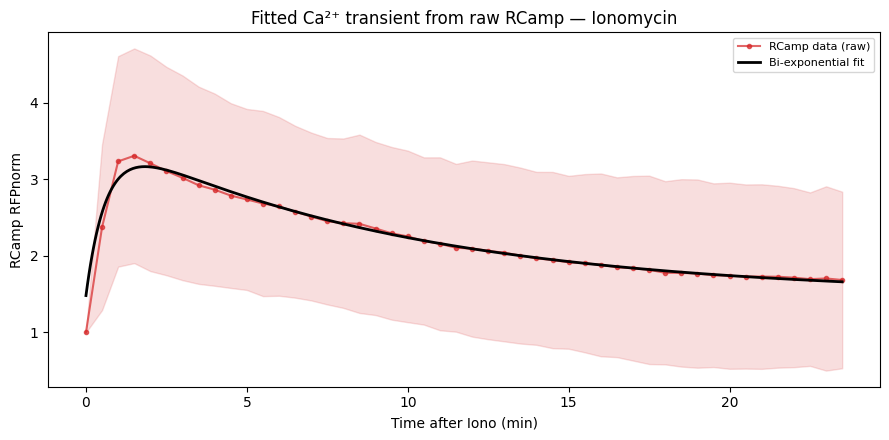

In [5]:
# Plot fit vs data
t_fine = np.linspace(0, t_post[-1], 500)
y_fine = full_model(t_fine, *popt)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_post, y_post, 'o-', markersize=3, color='tab:red', alpha=0.7, label='RCamp data (raw)')
ax.fill_between(t_post, y_post - s_post, y_post + s_post, alpha=0.15, color='tab:red')
ax.plot(t_fine, y_fine, 'k-', lw=2, label='Bi-exponential fit')
ax.set_xlabel('Time after Iono (min)')
ax.set_ylabel('RCamp RFPnorm')
ax.set_title('Fitted Ca²⁺ transient from raw RCamp — Ionomycin')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. RCamp variant identification via Hill calibration

Inverse Hill equation converts fluorescence to [Ca²⁺]: $[\text{Ca}^{2+}] = K_d \cdot \left( \frac{F - F_{\min}}{F_{\max} - F} \right)^{1/n}$

F_min ≈ baseline, F_max = F_min × dynamic range. The variant giving physiologically reasonable peak [Ca²⁺] (1–5 μM for 500 nM iono + 5 mM CaCl₂) is the correct one.

| Parameter | jRCaMP1a | RCaMP1h |
|-----------|----------|---------|
| K_d | 141 nM | 1.3 μM |
| Hill n | 1.5 | 2.5 |
| Dynamic range | 7 | 10.6 |
| Source | Kerruth et al. 2019 | Akerboom et al. 2013 |

### RCamp indicator kinetics — is fluorescence fast enough?

Ca²⁺ binding and fluorescence are **two separate steps**: cooperative Ca²⁺ binding to the calmodulin domain, then a rate-limiting conformational isomerization that switches on fluorescence (Kerruth et al. 2019, J Biol Chem 294:3934–3946).

For jRCaMP1a (closest characterized relative of RCaMP1h):
- **Association** (Ca²⁺ → fluorescence ON): dominant slow phase τ ≈ 250 ms (4.0 s⁻¹, 81% amplitude)
- **Dissociation** (Ca²⁺ → fluorescence OFF): τ ≈ 170–625 ms (biexponential)
- **In neurons**: τ_off = 327 ± 49 ms

The fluorescence lag (~0.25 s) is **~100× smaller than our 30 s sampling interval**, so the indicator faithfully reports [Ca²⁺] at each sampled time point. RCamp kinetics do not introduce a meaningful temporal bias.

### Temporal resolution limitation

The true Ca²⁺ peak occurs within seconds of ionomycin addition. RCamp would capture it within ~250 ms, but our 30 s sampling misses it. The resolved "peak" at t ≈ 1.5 min underestimates the true peak.

However, **CaMKK2 activation is the rate-limiting step** (τ ≈ 20 s, from CaMKK2 conformational activation), which is slower than both the Ca²⁺ influx (~seconds) and the unresolved peak. The sustained Ca²⁺ plateau (well-resolved at 30 s sampling) drives the majority of CaMKK2 activation. Any systematic bias from the unresolved initial spike is absorbed into the CaMKK2 arm parameters (kActCaMKK, KmCaM, betaCaMKK), which are inferred from the Iono AMPKAR data.


jRCaMP1a (Kd=141 nM, n=1.5, DR=7.0):
  Basal [Ca2+]:   0.0 nM
  Peak [Ca2+]:    0.112 uM  at t = 1.5 min
  Plateau [Ca2+]: 0.039 uM

RCaMP1h (Kd=1300 nM, n=2.5, DR=10.6):
  Basal [Ca2+]:   5.2 nM
  Peak [Ca2+]:    0.853 uM  at t = 1.5 min
  Plateau [Ca2+]: 0.491 uM


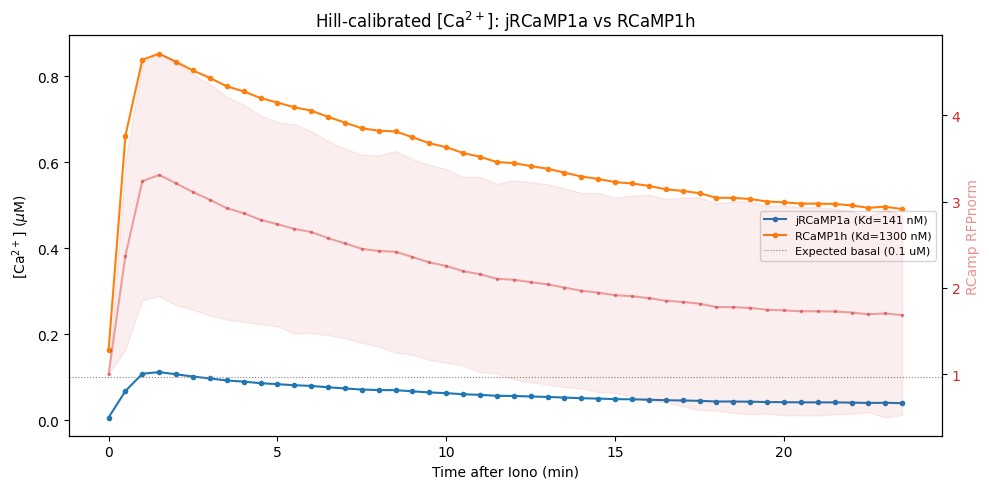


Expected for 500 nM Iono + 5 mM CaCl2: peak ~1-5 uM
=> jRCaMP1a ruled out (peak 0.112 uM, indicator saturated)
=> RCaMP1h is the likely variant (peak 0.853 uM)


In [6]:
# Hill calibration for both candidate variants
variants = {
    'jRCaMP1a': {'Kd_uM': 0.141, 'n': 1.5, 'DR': 7.0},
    'RCaMP1h':  {'Kd_uM': 1.3,   'n': 2.5, 'DR': 10.6},
}

F_min = baseline  # ~0.95

def hill_calibrate(F_raw, Kd_uM, n, DR):
    """Inverse Hill: raw fluorescence -> [Ca2+] in uM."""
    F_max = F_min * DR
    F_norm = (F_raw - F_min) / (F_max - F_min)
    F_norm = np.clip(F_norm, 1e-6, 1 - 1e-6)
    return Kd_uM * (F_norm / (1 - F_norm)) ** (1.0 / n)

for name, p in variants.items():
    Ca_hill = hill_calibrate(y_post, p['Kd_uM'], p['n'], p['DR'])
    print(f"\n{name} (Kd={p['Kd_uM']*1000:.0f} nM, n={p['n']}, DR={p['DR']}):")
    print(f"  Basal [Ca2+]:   {hill_calibrate(np.array([baseline]), p['Kd_uM'], p['n'], p['DR'])[0]*1000:.1f} nM")
    print(f"  Peak [Ca2+]:    {Ca_hill.max():.3f} uM  at t = {t_post[Ca_hill.argmax()]:.1f} min")
    print(f"  Plateau [Ca2+]: {Ca_hill[-1]:.3f} uM")

colors = {'jRCaMP1a': 'tab:blue', 'RCaMP1h': 'tab:orange'}

fig, ax = plt.subplots(figsize=(10, 5))
for name, p in variants.items():
    Ca_hill = hill_calibrate(y_post, p['Kd_uM'], p['n'], p['DR'])
    ax.plot(t_post, Ca_hill, 'o-', markersize=3, color=colors[name], label=f'{name} (Kd={p["Kd_uM"]*1000:.0f} nM)')
ax.axhline(0.1, color='grey', ls=':', lw=0.8, label='Expected basal (0.1 uM)')
ax.set_xlabel('Time after Iono (min)')
ax.set_ylabel('[Ca$^{2+}$] ($\\mu$M)')
ax.legend(fontsize=8, loc='center right')

ax_raw = ax.twinx()
ax_raw.plot(t_post, y_post, 's-', markersize=2, color='tab:red', alpha=0.4, label='Raw RCamp')
ax_raw.fill_between(t_post, y_post - s_post, y_post + s_post, alpha=0.08, color='tab:red')
ax_raw.set_ylabel('RCamp RFPnorm', color='tab:red', alpha=0.5)
ax_raw.tick_params(axis='y', labelcolor='tab:red')

plt.title('Hill-calibrated [Ca$^{2+}$]: jRCaMP1a vs RCaMP1h')
plt.tight_layout()
plt.show()

print("\nExpected for 500 nM Iono + 5 mM CaCl2: peak ~1-5 uM")
print("=> jRCaMP1a ruled out (peak 0.112 uM, indicator saturated)")
print("=> RCaMP1h is the likely variant (peak 0.853 uM)")

## 4. Hill-calibrated bi-exponential fit

Apply RCaMP1h Hill calibration pointwise to raw data, then fit bi-exponential to the [Ca²⁺] trace. This preserves the exact data shape (nonlinear compression at high [Ca²⁺]) while producing a smooth continuous function for the ODE solver.

Uncertainty propagated via first-order Taylor expansion of the inverse Hill transform.

Bi-exponential fit to Hill-calibrated [Ca2+] (RCaMP1h):
-------------------------------------------------------
  Ca_plat (uM)       =   0.4089 +/- 0.4337
  A_ca (uM)          =   0.5074 +/- 0.2729
  tau_rise (min)     =   0.5593 +/- 1.1819
  tau_decay (min)    =  12.1712 +/- 26.1027

  Peak [Ca2+]:  0.829 uM at t = 1.67 min (100 s)
  Plateau:      0.409 uM
  R² = 0.9915


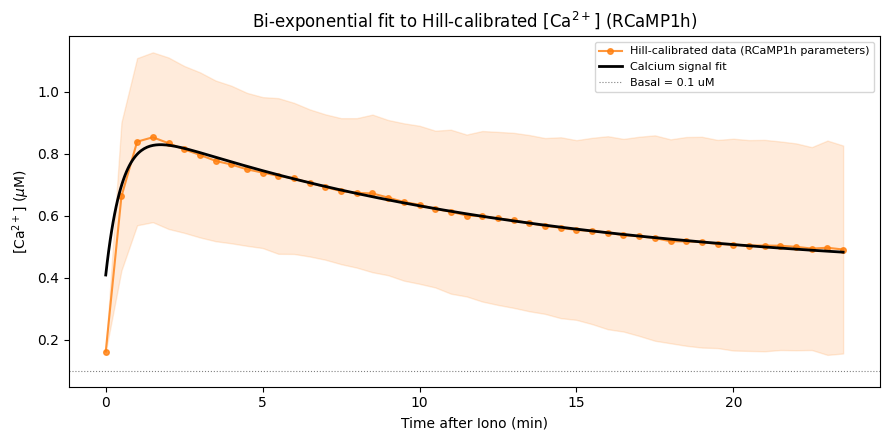

In [7]:
# Hill-calibrate raw data using RCaMP1h, then re-fit bi-exponential
Kd_uM = 1.3; n_hill = 2.5; DR = 10.6

Ca_data = hill_calibrate(y_post, Kd_uM, n_hill, DR)  # pointwise [Ca2+] in uM

# Propagate std through Hill transform (first-order approximation)
# dCa/dF at each point
F_max = F_min * DR
F_norm = np.clip((y_post - F_min) / (F_max - F_min), 1e-6, 1 - 1e-6)
# derivative of inverse Hill: dCa/dF_norm = (Kd/n) * (F_norm/(1-F_norm))^(1/n - 1) * 1/(1-F_norm)^2
dCa_dFnorm = (Kd_uM / n_hill) * (F_norm / (1 - F_norm)) ** (1.0/n_hill - 1) / (1 - F_norm)**2
dFnorm_dF = 1.0 / (F_max - F_min)
Ca_std = np.abs(dCa_dFnorm * dFnorm_dF) * s_post

# Fit bi-exponential to Hill-calibrated data (in uM, time in minutes)
# Exclude points with zero std
mask_v = Ca_std > 0
t_v = t_post[mask_v]
Ca_v = Ca_data[mask_v]
Ca_s = Ca_std[mask_v]

# Set basal offset: Hill gives ~0 at baseline, but we know basal = 0.1 uM
Ca_basal_hill = 0.1  # uM, fixed offset

def hill_biexp(t, Ca_plat, A_ca, tau_r, tau_d):
    """Bi-exponential in [Ca2+] space. Returns Ca in uM."""
    return Ca_plat + A_ca * (1 - np.exp(-t / tau_r)) * np.exp(-t / tau_d)

p0_hill = [0.3, 0.7, 0.3, 8.0]
bounds_hill = ([0.05, 0.1, 0.01, 1], [1.0, 3.0, 3, 50])

popt_hill, pcov_hill = curve_fit(hill_biexp, t_v, Ca_v, p0=p0_hill,
                                  sigma=Ca_s, absolute_sigma=True, bounds=bounds_hill)
perr_hill = np.sqrt(np.diag(pcov_hill))

Ca_plat_fit, A_ca_fit, tau_r_fit, tau_d_fit = popt_hill

# Peak
t_peak_hill = tau_r_fit * tau_d_fit / (tau_r_fit + tau_d_fit) * np.log(1 + tau_d_fit / tau_r_fit)
Ca_peak_hill = hill_biexp(t_peak_hill, *popt_hill)

# R²
Ca_pred = hill_biexp(t_v, *popt_hill)
ss_res = np.sum((Ca_v - Ca_pred)**2)
ss_tot = np.sum((Ca_v - np.mean(Ca_v))**2)
r_sq_hill = 1 - ss_res / ss_tot

print("Bi-exponential fit to Hill-calibrated [Ca2+] (RCaMP1h):")
print("-" * 55)
for nm, v, e in zip(['Ca_plat (uM)', 'A_ca (uM)', 'tau_rise (min)', 'tau_decay (min)'], popt_hill, perr_hill):
    print(f"  {nm:18s} = {v:8.4f} +/- {e:.4f}")
print(f"\n  Peak [Ca2+]:  {Ca_peak_hill:.3f} uM at t = {t_peak_hill:.2f} min ({t_peak_hill*60:.0f} s)")
print(f"  Plateau:      {Ca_plat_fit:.3f} uM")
print(f"  R² = {r_sq_hill:.4f}")

# Plot
t_fine_min = np.linspace(0, t_post[-1], 500)
Ca_fit_fine = hill_biexp(t_fine_min, *popt_hill)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_post, Ca_data, 'o-', markersize=4, color='tab:orange', alpha=0.8, label='Hill-calibrated data (RCaMP1h parameters)')
ax.fill_between(t_post, Ca_data - Ca_std, Ca_data + Ca_std, alpha=0.15, color='tab:orange')
ax.plot(t_fine_min, Ca_fit_fine, 'k-', lw=2, label='Calcium signal fit')
ax.axhline(Ca_basal_hill, color='grey', ls=':', lw=0.8, label=f'Basal = {Ca_basal_hill} uM')
ax.set_xlabel('Time after Iono (min)')
ax.set_ylabel('[Ca$^{2+}$] ($\\mu$M)')
ax.set_title('Bi-exponential fit to Hill-calibrated [Ca$^{2+}$] (RCaMP1h)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Save fitted parameters

Save to `models/calcium_signal_iono.json` for use by inference scripts. Includes Hill calibration metadata, fit parameters in μM directly, and experimental conditions.

In [8]:
save_path = '../models/calcium_signal_iono.json'

output = {
    "description": "Bi-exponential fit to Hill-calibrated [Ca2+] from RCaMP1h Iono data",
    "data_source": "260307_HeLaAMPKAR3_LKB1wt_kd.xlsx, columns 16-17 (MEAN_RFPnorm, STD_RFPnorm)",
    "calibration": {
        "method": "Inverse Hill equation (RCaMP1h)",
        "variant": "RCaMP1h",
        "Kd_uM": Kd_uM,
        "Hill_n": n_hill,
        "dynamic_range": DR,
        "F_min": float(F_min),
        "F_max": float(F_min * DR),
        "source": "Akerboom et al. 2013",
    },
    "model": "Ca(t) = Ca_plat + A_ca * (1 - exp(-t/tau_rise)) * exp(-t/tau_decay), t in minutes, Ca in uM",
    "fit_params": {
        "Ca_plat_uM": float(Ca_plat_fit),
        "A_ca_uM": float(A_ca_fit),
        "tau_rise_s": float(tau_r_fit * 60),
        "tau_decay_s": float(tau_d_fit * 60),
    },
    "Ca_basal_uM": 0.1,
    "derived": {
        "t_peak_s": float(t_peak_hill * 60),
        "Ca_peak_uM": float(Ca_peak_hill),
        "Ca_plateau_uM": float(Ca_plat_fit),
    },
    "fit_quality": {"R_squared": float(r_sq_hill)},
    "experimental_conditions": {
        "ionomycin_nM": 500,
        "extracellular_CaCl2_mM": 5.0,
        "Fmax_calibration": False,
    },
    "units": {"time": "seconds", "concentration": "uM"},
    "notes": [
        "Hill-calibrated: raw fluorescence -> [Ca2+] via inverse Hill (RCaMP1h), then bi-exponential fit.",
        "Ca_basal = 0.1 uM used for t < 0 (Hill gives ~0 at baseline fluorescence).",
        "Fit params are in uM directly — no separate scaling step needed.",
    ]
}

with open(save_path, 'w') as f:
    json.dump(output, f, indent=4)
print(f"Saved to {save_path}")

Saved to ../models/calcium_signal_iono.json


## 6. JAX-compatible Ca(t) for ODE solvers

`load_calcium_signal()` loads the JSON and returns a JIT-compatible function. Usage in inference: `ca_func, _ = load_calcium_signal('models/calcium_signal_iono.json')`

In [9]:
import jax.numpy as jnp

def load_calcium_signal(json_path):
    """Load fitted calcium signal and return a JAX-compatible Ca(t) function.
    
    Returns:
        ca_func: callable(t_sec) -> [Ca2+] in uM, compatible with jax.jit
        params_dict: the full parameter dictionary
    """
    with open(json_path, 'r') as f:
        params = json.load(f)
    
    fp = params['fit_params']
    Ca_plat  = fp['Ca_plat_uM']
    A_ca     = fp['A_ca_uM']
    tau_rise = fp['tau_rise_s'] / 60.0   # -> minutes (model uses minutes internally)
    tau_decay = fp['tau_decay_s'] / 60.0
    Ca_basal = params['Ca_basal_uM']
    
    def ca_func(t_sec):
        """[Ca2+] in uM at time t (seconds). t=0 is drug addition."""
        t_min = jnp.maximum(t_sec / 60.0, 0.0)
        ca = Ca_plat + A_ca * (1.0 - jnp.exp(-t_min / tau_rise)) * jnp.exp(-t_min / tau_decay)
        return jnp.where(t_sec >= 0, ca, Ca_basal)
    
    return ca_func, params

# Verify: JAX function matches numpy Hill-calibrated data at sample points
ca_func, _ = load_calcium_signal(save_path)
t_test = np.array([0, 30, 60, 120, 300, 600, 900])
print('Ca(t) from JAX function:')
print(f"{'t (s)':>8s}  {'Ca (uM)':>10s}")
for t in t_test:
    print(f'{t:8d}  {float(ca_func(float(t))):10.4f}')

Ca(t) from JAX function:
   t (s)     Ca (uM)
       0      0.4089
      30      0.6967
      60      0.7981
     120      0.8274
     300      0.7454
     600      0.6320
     900      0.5569


## 7. Notes & remaining tasks before Iono inference

**Basal CaMKK2 activity is too high with nominal parameters.** Testing with `solve_traj` shows CaMKK_act ≈ 0.70 at steady state (Ca_basal = 0.1 μM), and pAMPKAR ratio ≈ 0.85 — both unrealistically high. This is expected: the calcium cascade fixed params (`kOnCaM`, `kOffCaM`, `kActCaMKK`, `KmCaM`, `kDeactCaMKK`) are placeholder values from the design doc and need tuning.

**Tasks before running Iono inference:**

1. **Get 2DG inference results** — Run Pathfinder for Models 5/6 (`MA_nonessential_phos`, `MM_nonessential_phos`) on 2DG data. These posteriors fix the core AMPK pathway parameters.
2. **Prior elicitation for CaMKK2 cascade params** — Set priors for `betaCaMKK` and the calcium cascade fixed params (`kOnCaM`, `kOffCaM`, `kActCaMKK`, `KmCaM`, `kDeactCaMKK`). Constraint: basal CaMKK_act should be low (< 0.1) at Ca_basal = 0.1 μM.
3. **Decide which CaMKK2 params to infer vs fix** — The 5 cascade params + `betaCaMKK` are 6 new params. Likely fix cascade params from literature and infer only `betaCaMKK` (+ possibly `kActCaMKK` or `kDeactCaMKK`).
4. **Create Iono inference shell script** — Analogous to `inference_run_MA_nonessential_phos.sh` but for `MA_phos_CaMKK2`/`MM_phos_CaMKK2`, using fixed 2DG posteriors + Ca(t) + free CaMKK2 params only.
5. **Model selection** — Compare all models (3–6 on 2DG, then CaMKK2 extensions on Iono) via ELPD.